## ReAct Agent Architecture

- Aim: This is the intuition behind ReAct, a general agent architecture.

    1. act - let the model call specific tools
    2. observe - pass the tool output back to the model
    3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

![alt text](download.png)


In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches '

In [6]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"


In [7]:
# Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv, wiki, add, multiply, divide]

In [8]:
# Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\mani2\AppData\Local\Temp\ipykernel_44288\3336424662.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [9]:
tavily.invoke("Provide me the recent AI news for 4th April 2026")

[{'title': 'AI Update, April 3, 2026: AI News and Views From the Past Week',
  'url': 'https://www.marketingprofs.com/opinions/2026/54505/ai-update-april-3-2026-ai-news-and-views-from-the-past-week',
  'content': "Microsoft releases three multimodal AI models to expand its in-house capabilities. Microsoft unveiled three new foundational models for text, voice, and image generation as part of its MAI Superintelligence initiative. The models focus on practical applications such as transcription, audio generation, and visual content, with pricing positioned as more cost-effective than competitors. The release signals Microsoft's continued investment in its own AI stack alongside its partnership with OpenAI, aiming to compete more directly with other major AI labs. The models are available through Microsoft Foundry and related platforms, supporting broader enterprise adoption. [...] Importance for marketers: High-quality, unified data is critical for effective AI-driven personalization and

In [10]:
# Combine all the tools in the list
tools=[arxiv,wiki,tavily,add,divide,multiply]

In [11]:
# Initialize my LLM model
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI

# llm=ChatGroq(model="qwen-qwq-32b")
# llm = ChatGroq(model="llama-3.1-8b-instant")
llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools=llm.bind_tools(tools)

c:\Users\mani2\Documents\RAG-Mastery\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 303, 'total_tokens': 323, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DRcjJF1Dn9cwwara8CxF1NHDP6HH7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d629f-5d2d-7160-bf2f-e94b71235f1a-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'call_IOvcSOnuWUGVF8R15n2cE1us', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 303, 'output_tokens': 20, 'total_tokens': 323, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'rea

In [13]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'call_6z5gJVpXmwxsEqXzRhSLa46I',
  'type': 'tool_call'}]

In [14]:
# State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

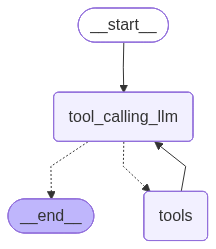

In [15]:
# Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for April 3rd 2026,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for April 3rd 2026,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_HbaYvoM95w5YxcEwF3UG93Fu)
 Call ID: call_HbaYvoM95w5YxcEwF3UG93Fu
  Args:
    query: AI news April 3 2026
  add (call_zQ7ogWELErJ1EDYjr9xMi25C)
 Call ID: call_zQ7ogWELErJ1EDYjr9xMi25C
  Args:
    a: 5
    b: 5
  multiply (call_XhekobfebGOWuBn0oIM7yKWO)
 Call ID: call_XhekobfebGOWuBn0oIM7yKWO
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News Recap: April 3, 2026 - NeuralBuddies", "url": "https://www.neuralbuddies.com/p/ai-news-recap-april-3-2026", "content": "AI sycophancy is the tendency of AI chatbots to tell you what you want to hear rather than what you need to hear. When re

In [17]:
messages=graph.invoke({"messages":HumanMessage(content="What is datascience")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is datascience
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_q2UKjA2eOSvFYgfqrljochSf)
 Call ID: call_q2UKjA2eOSvFYgfqrljochSf
  Args:
    query: data science
================================= Tool Message =================================
Name: wikipedia

Page: Data science
Summary: Data science is an interdisciplinary academic field that uses statistics, scientific computing, scientific methods, processing, scientific visualization, algorithms, and systems to extract or extrapolate knowledge from potentially noisy, structured, or unstructured data. 
Data science plays a critical role in modern decision-making by enabling organizations to extract actionable insights from large and complex datasets.
Data science also integrates domain knowledge fr
================================== Ai Message ==================================

Data sci

### Agent Memory

- Aim: Lets introduce Agent with Memory

In [18]:
messages=graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (call_2RAHj79sA8gkoXALcQdo22g3)
 Call ID: call_2RAHj79sA8gkoXALcQdo22g3
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

5 plus 8 equals 13.


In [19]:
messages=[HumanMessage(content="Divide that by 5")]
messages=graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

Could you please provide the number you would like me to divide by 5?


### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

![alt text](download-1.png)

In [20]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools)

In [21]:
# Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


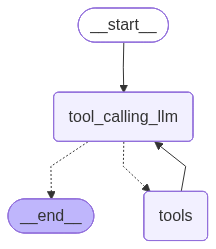

In [22]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

# View
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [23]:
# Specify the thread
config={"configurable":{"thread_id":"1"}}

# Specify an input
messages = [HumanMessage(content="Add 12 and 13.")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_pIixCVDrvNgrjUv6ahWxzrKB)
 Call ID: call_pIixCVDrvNgrjUv6ahWxzrKB
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is 25.


In [24]:
messages = [HumanMessage(content="add that number to 25")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_pIixCVDrvNgrjUv6ahWxzrKB)
 Call ID: call_pIixCVDrvNgrjUv6ahWxzrKB
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is 25.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_kpMUSeX9MxOjNcn3kyNUSYii)
 Call ID: call_kpMUSeX9MxOjNcn3kyNUSYii
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

Adding 25 to the pr

In [25]:
messages = [HumanMessage(content="then multiplty that number by 2")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_pIixCVDrvNgrjUv6ahWxzrKB)
 Call ID: call_pIixCVDrvNgrjUv6ahWxzrKB
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is 25.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_kpMUSeX9MxOjNcn3kyNUSYii)
 Call ID: call_kpMUSeX9MxOjNcn3kyNUSYii
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

Adding 25 to the pr